# Cell Segmentation Project:

### Importing Packages:

In [35]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from skimage.io import imread
from skimage.io import imsave
from skimage import measure
from skimage.measure import find_contours
from collections import Counter
from cellpose import models
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from io import BytesIO
from PIL import Image
import napari

imageGT = imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e4_wD2_f2_nuc_ann1.tif")
imageSeg = imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e4_wD2_f2_c2_cp_masks.png")
realImage = imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e4_wD2_f2_c2.tif")

### Uploading Images:

In [36]:
#DNA CPSAM, DNA CPv3, and RNA CPv3:
data = {
    "e1_wB10_f2_c2" : {"image_dna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e1_wB10_f2_c2.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e1_wB10_f2_nuc_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2Files/e1_wB10_f2_c2_cp_masks.png"), "seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2FilesCPv3/e1_wB10_f2_c2_cp_masks.png")},
    "e2_wD11_f2_c2" : {"image_dna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e2_wD11_f2_c2.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e2_wD11_f2_nuc_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2Files/e2_wD11_f2_c2_cp_masks.png"), "seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2FilesCPv3/e2_wD11_f2_c2_cp_masks.png")},
    "e2_wG2_f2_c2" : {"image_dna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e2_wG2_f2_c2.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e2_wG2_f2_nuc_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2Files/e2_wG2_f2_c2_cp_masks.png"), "seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2FilesCPv3/e2_wG2_f2_c2_cp_masks.png")},
    "e3_wD11_f3_c2" : {"image_dna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e3_wD11_f3_c2.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e3_wD11_f3_nuc_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2Files/e3_wD11_f3_c2_cp_masks.png"), "seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2FilesCPv3/e3_wD11_f3_c2_cp_masks.png")},
    "e4_wD2_f2_c2" : {"image_dna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e4_wD2_f2_c2.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e4_wD2_f2_nuc_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2Files/e4_wD2_f2_c2_cp_masks.png"), "seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c2FilesCPv3/e4_wD2_f2_c2_cp_masks.png")},
    
    "e1_wB10_f2_c5" : {"image_rna" : imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e1_wB10_f2_c5.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e1_wB10_f2_soma_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e1_wB10_f2_c5_cp_masks.png")},
    "e2_wD11_f2_c5" : {"image_rna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e2_wD11_f2_c5.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e2_wD11_f2_soma_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e2_wD11_f2_c5_cp_masks.png")},
    "e2_wG2_f2_c5" : {"image_rna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e2_wG2_f2_c5.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e2_wG2_f2_soma_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e2_wG2_f2_c5_cp_masks.png")},
    "e3_wD11_f3_c5" : {"image_rna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e3_wD11_f3_c5.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e3_wD11_f3_soma_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e3_wD11_f3_c5_cp_masks.png")},
    "e4_wD2_f2_c5" : {"image_rna": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e4_wD2_f2_c5.tif"), "gt_nuc": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/2025_06_segmentation/e4_wD2_f2_soma_ann1.tif"), "seg_nuc_CPSAM": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/c5Files/e4_wD2_f2_c5_cp_masks.png")}
}

#RNA CPv3:
stacked_image1_e1_wB10_f2 = np.stack((data["e1_wB10_f2_c2"]["gt_nuc"], data["e1_wB10_f2_c5"]["gt_nuc"]), axis=0)
imsave('/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image1.tif', np.stack((data["e1_wB10_f2_c2"]["gt_nuc"], data["e1_wB10_f2_c5"]["gt_nuc"]), axis=0))
stacked_image2_e2_wD11_f2 = np.stack((data["e2_wD11_f2_c2"]["gt_nuc"], data["e2_wD11_f2_c5"]["gt_nuc"]), axis=0)
imsave('/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image2.tif', stacked_image2_e2_wD11_f2)
stacked_image3_e2_wG2_f2 = np.stack((data["e2_wG2_f2_c2"]["gt_nuc"], data["e2_wG2_f2_c5"]["gt_nuc"]), axis=0)
imsave('/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image3.tif', stacked_image3_e2_wG2_f2)
stacked_image4_e3_wD11_f3 = np.stack((data["e3_wD11_f3_c2"]["gt_nuc"], data["e3_wD11_f3_c5"]["gt_nuc"]), axis=0)
imsave('/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image4.tif', stacked_image4_e3_wD11_f3)
stacked_image5_e4_wD2_f2 = np.stack((data["e4_wD2_f2_c2"]["gt_nuc"], data["e4_wD2_f2_c5"]["gt_nuc"]), axis=0)
imsave('/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image5.tif', stacked_image5_e4_wD2_f2)
data["e1_wB10_f2_c5"].update({"seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image1_cp_masks.png")})
data["e2_wD11_f2_c5"].update({"seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image2_cp_masks.png")})
data["e2_wG2_f2_c5"].update({"seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image3_cp_masks.png")})
data["e3_wD11_f3_c5"].update({"seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image4_cp_masks.png")})
data["e4_wD2_f2_c5"].update({"seg_nuc_CPv3": imread("/Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image5_cp_masks.png")})


/opt/miniconda3/envs/cellSeg/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image1.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/cellSeg/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image2.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/cellSeg/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image3.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/cellSeg/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/ofri.geva/Desktop/CellSegmentationProject/3Dimages/stacked_image4.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/cellSeg/lib/python3.13/site-packages/skimage/_s

### Pixel Accuracy Calculator:


the accuracy of the segmented image in comparison to the ground truth (in %) is:


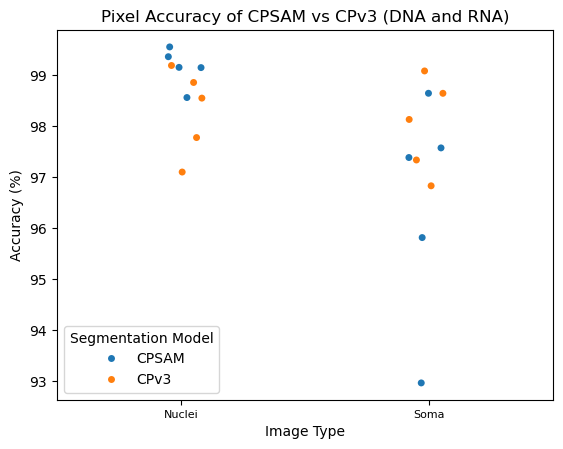

In [37]:
#This function takes two inputs: a ground truth image and a segmented image. It compares the corresponding pixels in both images to determine how accurately the segmented image matches the ground truth. 
#The function returns a float representing the percentage of pixels correlated to eachother in both images.
def pixel_accuracy_calculator(imageGroundTruth, segmentation):
    height = imageGroundTruth.shape[0]
    width = imageGroundTruth.shape[1]
    totalPixels = height * width    
    #A mask is a boolean array used to analyze data 
    #Instead of having mutliple numbers to represent nuclei, the mask makes the data simpler:
    #nuclei = true (aka if pixel > 0) and background = false (if pixel = 0)
    #mask1 and mask2 are both arrays made up of either True or False.
    maskGT = (imageGroundTruth > 0)
    maskSeg = (segmentation > 0)
    #In order to calculate agreement, create an array of True/False values based on if both masks "agree" on cell amd background
    #agreement is an array. np.logical_and checks if both masks say True/False
    agreement = np.logical_and(maskGT, maskSeg) | np.logical_and(maskGT == 0, maskSeg == 0)
    #np.sum() adds up all the True values (as 1s)
    agreementCount = np.sum(agreement)
    accuracy = agreementCount/totalPixels
    return(float(accuracy)*100)
print("the accuracy of the segmented image in comparison to the ground truth (in %) is:")
pixel_accuracy_calculator(imageGT, imageSeg)


#Calculating accuracy for CPSAM DNA Segmentation, CPSAM RNA Segmentation, CPv3 DNA Segmentation, CPv3 RNA Segmentation:
key_to_name = {
    "seg_nuc_CPSAM": "CPSAM",
    "seg_nuc_CPv3": "CPv3"
}
accuracies = []
for seg_key in key_to_name:
    for idx, (id, data_dict) in enumerate(data.items()):
        accuracy = pixel_accuracy_calculator(
            data_dict["gt_nuc"],
            data_dict[seg_key]
        )
        img_type = "Nuclei" if idx < 5 else "Soma"
        accuracies.append({"Image": id, "Accuracy (%)": accuracy, "Image Type": img_type, "Model": key_to_name[seg_key]})

df = pd.DataFrame(accuracies)
sns.stripplot(data=df, x="Image Type", y="Accuracy (%)", hue="Model", dodge=False, jitter=True)
plt.xticks(fontsize=8)
plt.title("Pixel Accuracy of CPSAM vs CPv3 (DNA and RNA)")
plt.legend(title="Segmentation Model")
plt.savefig("pixel_accuracy_CPSAM_vs_CPv3_DNA_and_RNA.png", dpi=300)
plt.show()



### Pixel Accuracy Visual Representation:


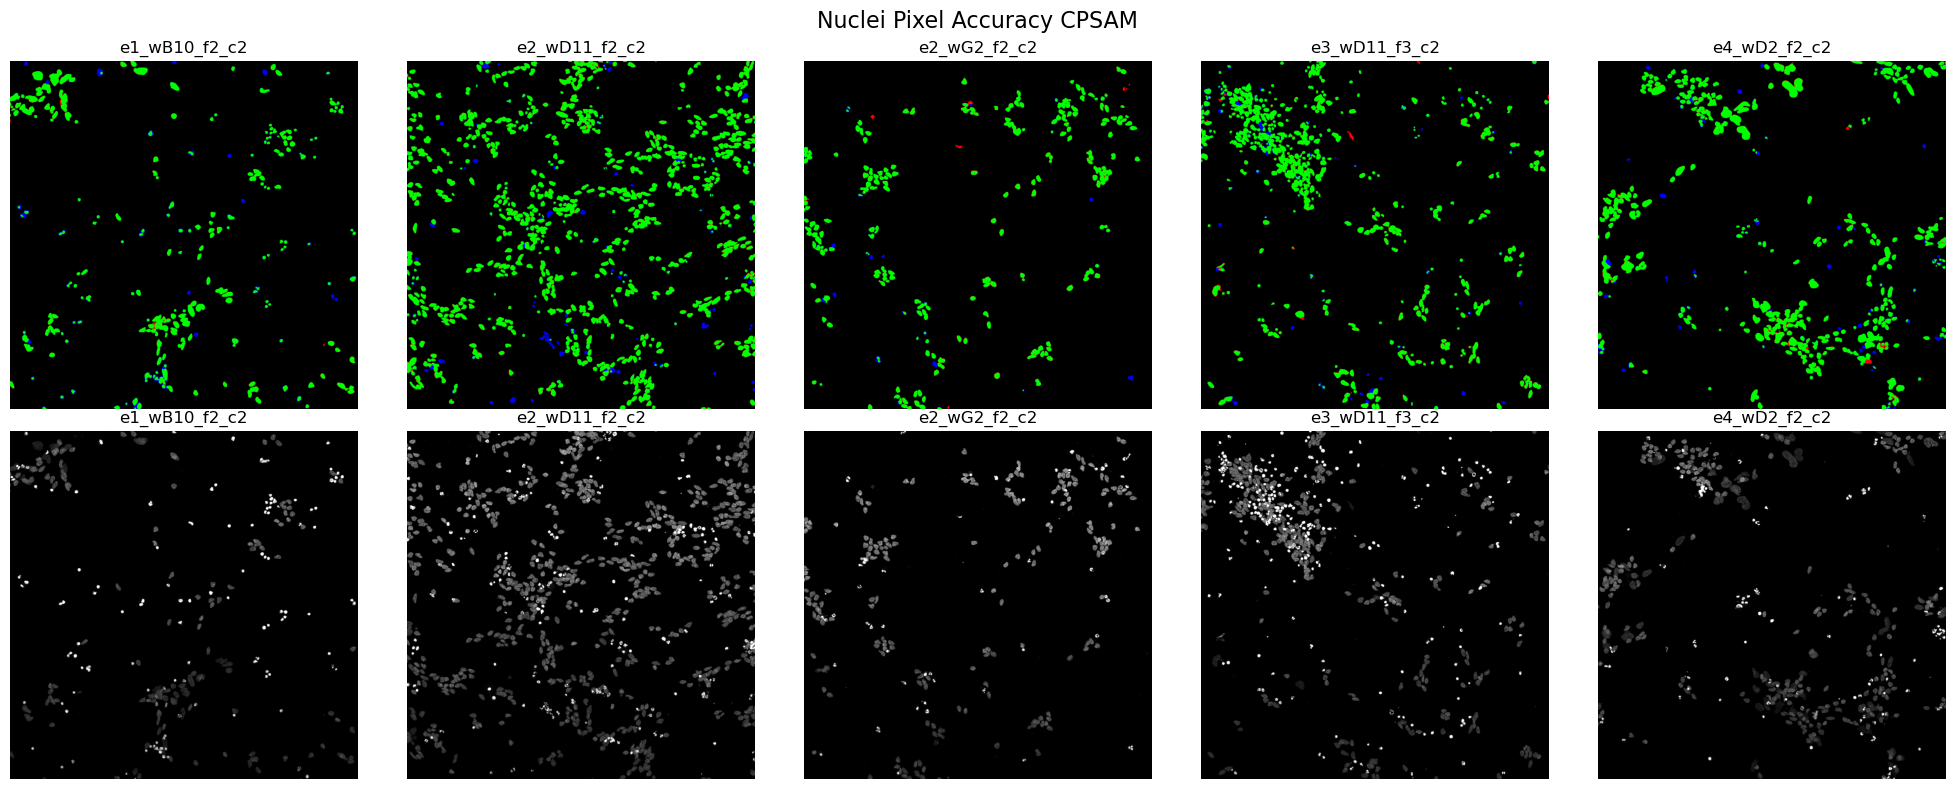

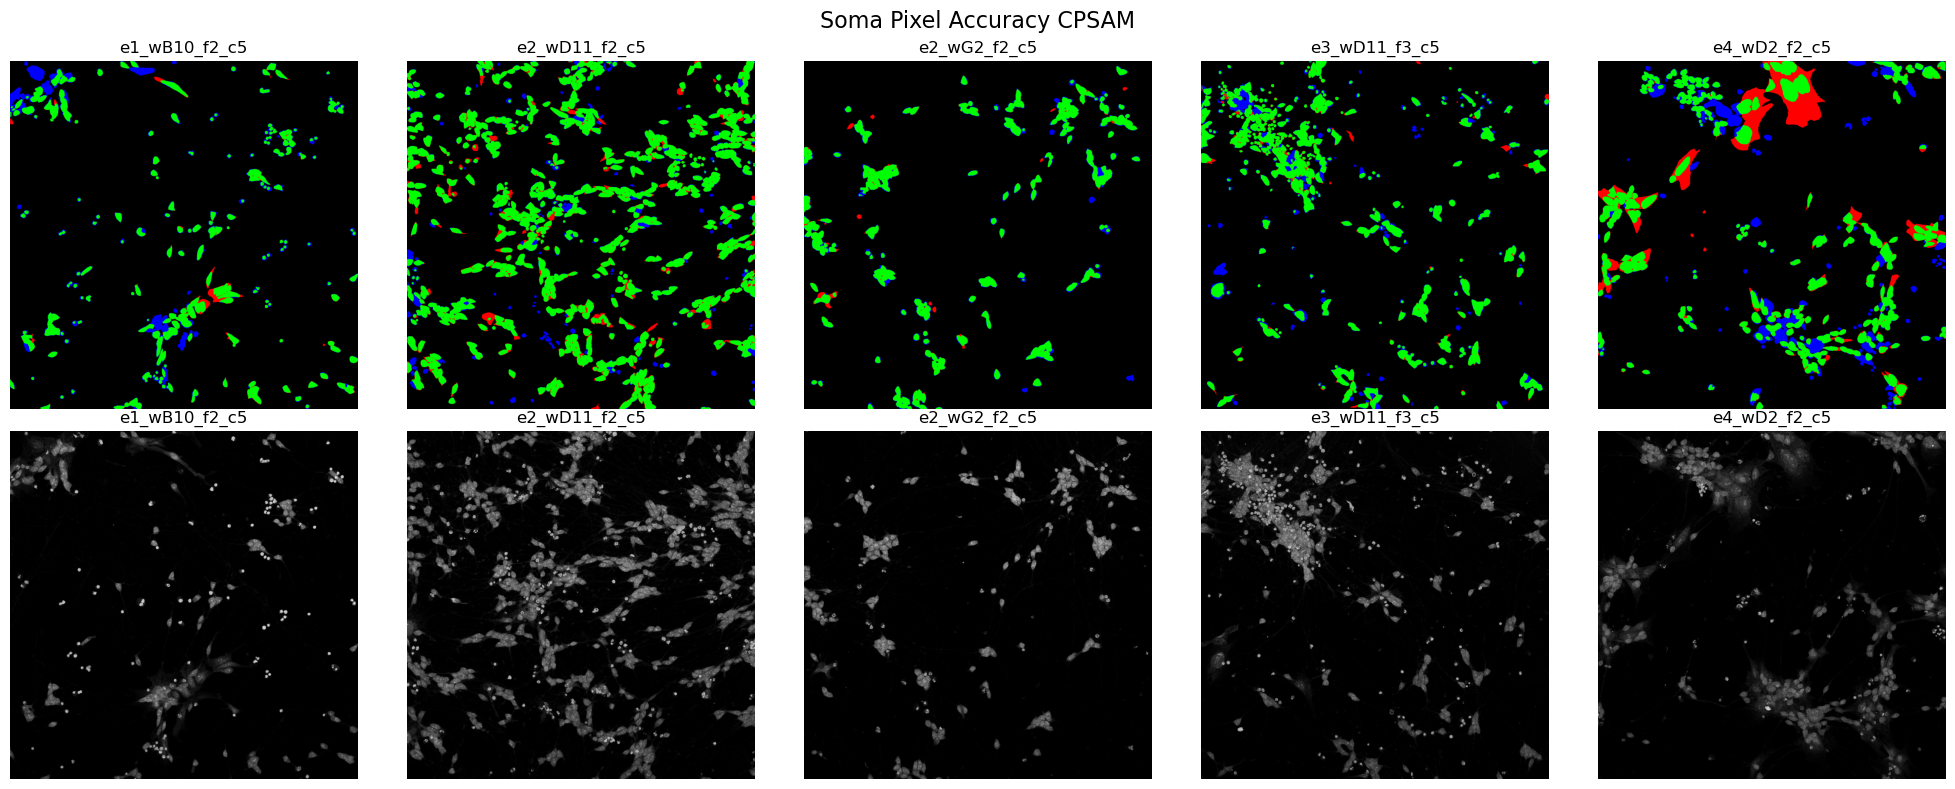

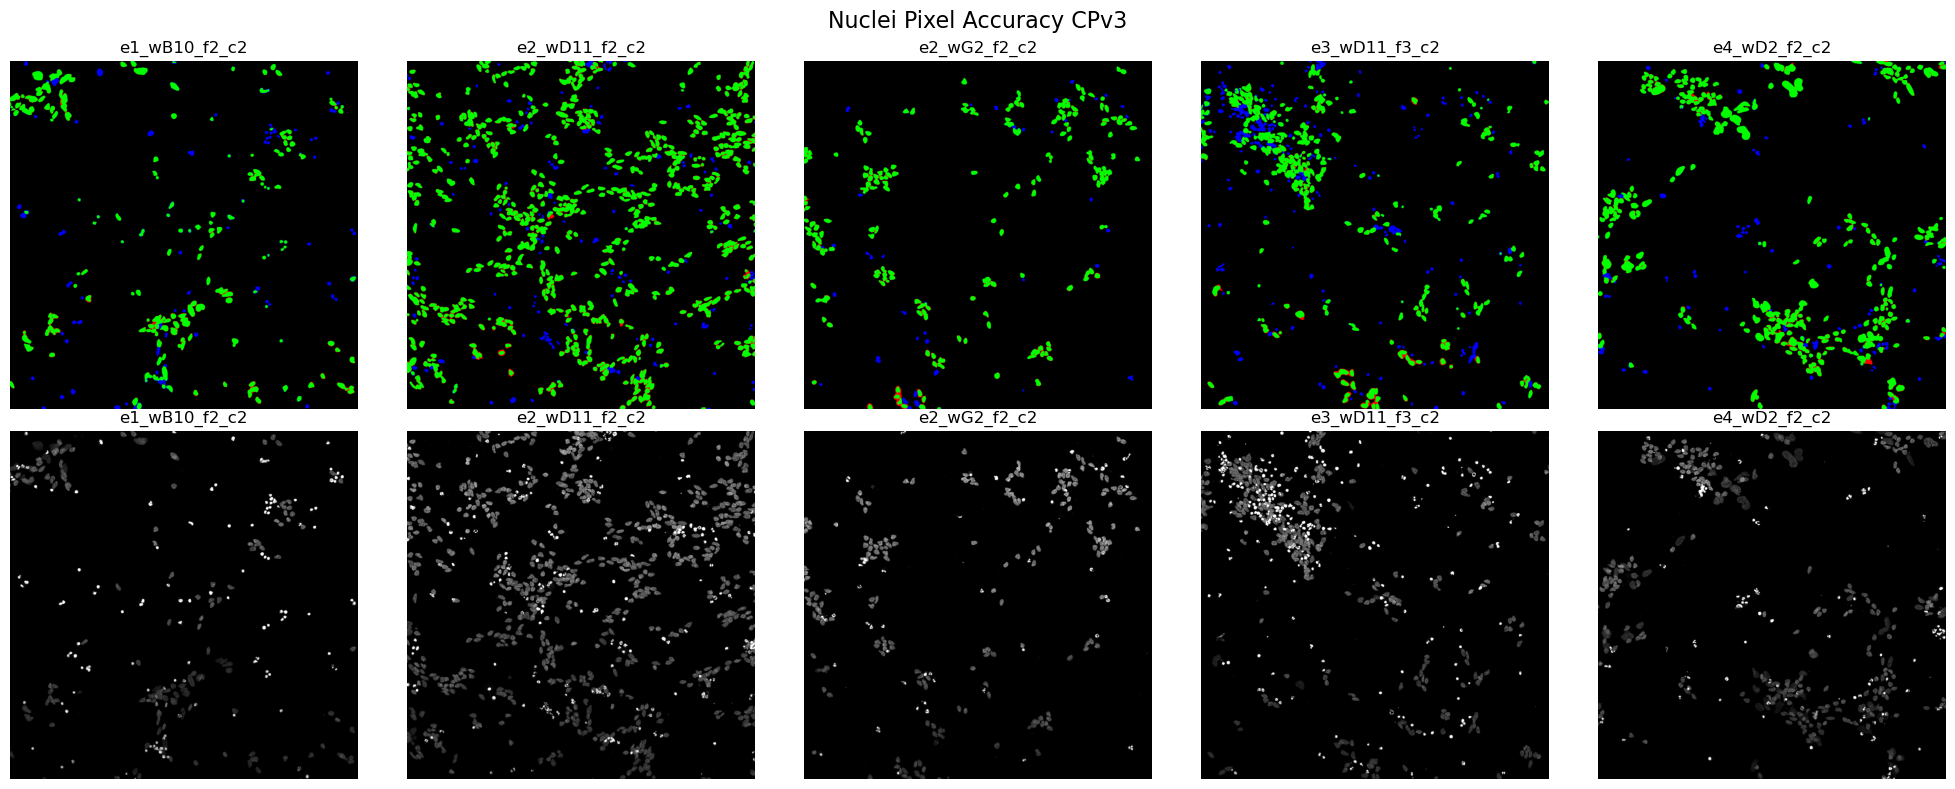

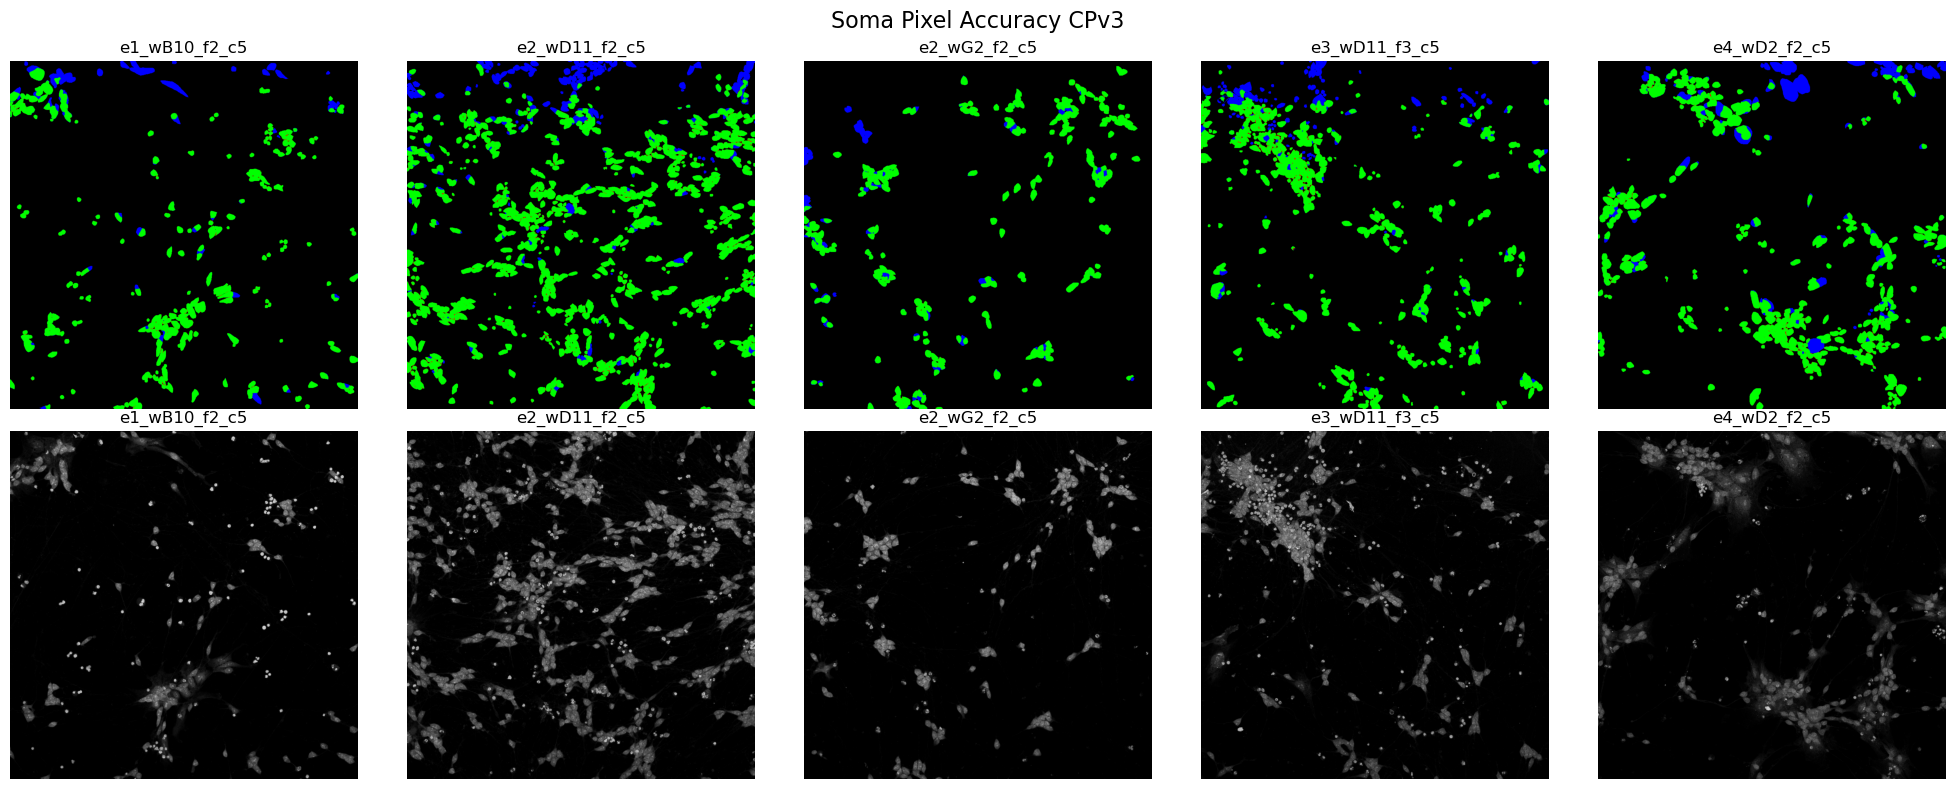

In [38]:
#This function takes two inputs: a ground truth image and a segmented image. Using masks, it 
def create_tp_fp_fn_image(imageGroundTruth, segmentation):
    height = imageGroundTruth.shape[0]
    width = imageGroundTruth.shape[1]
    maskGT = (imageGroundTruth > 0)
    maskSeg = (segmentation > 0)
    #We first define the image as an array of 0s
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)
    #True positives are set to green
    rgb_image[np.logical_and(maskGT, maskSeg)] = [0, 255, 0]
    #False negatives are set to blue
    rgb_image[np.logical_and(maskGT, np.logical_not(maskSeg))] = [0, 0, 255]
    #False positives are set to red
    rgb_image[np.logical_and(np.logical_not(maskGT), maskSeg)] = [255, 0, 0]
    return rgb_image

#This function takes in our data dictionary, an image key, segmentation key, and ground truth key.
#The function plots the images created by create_tp_fp_fn_image
def plot_all_tp_fp_fn(data, image_key, seg_key, gt_key, title_prefix):
    #Keys is a list to store the names of images we are plotting
    keys = []
    for image_name in data:
        image_info = data[image_name]
        #checking if data has all the information we need
        if image_key in image_info and seg_key in image_info and gt_key in image_info:
            keys.append(image_name)  # save the name if it has everything

    n = len(keys)  # how many images we will plot
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    fig.suptitle(title_prefix, fontsize=16)

    for col, image_name in enumerate(keys):
        image_info = data[image_name]
        #Row 1: True Pos/False Pos/False Neg overlay
        tp_fp_fn_img = create_tp_fp_fn_image(image_info[gt_key], image_info[seg_key])
        axes[0, col].imshow(tp_fp_fn_img)
        axes[0, col].set_title(image_name)
        axes[0, col].axis("off")

        # Row 2: Original grayscale image
        axes[1, col].imshow(image_info[image_key], cmap="gray")
        axes[1, col].set_title(image_name)
        axes[1, col].axis("off")
    plt.tight_layout()

    plt.show()

#DNA CPSAM
plot_all_tp_fp_fn(data, image_key="image_dna", seg_key="seg_nuc_CPSAM", gt_key="gt_nuc", title_prefix="Nuclei Pixel Accuracy CPSAM")
#RNA CPSAM
plot_all_tp_fp_fn( data, image_key="image_rna", seg_key="seg_nuc_CPSAM", gt_key="gt_nuc", title_prefix="Soma Pixel Accuracy CPSAM")
#DNA CPv3
plot_all_tp_fp_fn( data, image_key="image_dna", seg_key="seg_nuc_CPv3", gt_key="gt_nuc", title_prefix="Nuclei Pixel Accuracy CPv3")
#RNA CPv3
plot_all_tp_fp_fn(data, image_key="image_rna", seg_key="seg_nuc_CPv3", gt_key="gt_nuc", title_prefix="Soma Pixel Accuracy CPv3")


### Comparing both Nuclei & Soma: Ground Truth, CPSAM & CPv3 Segmentations, and Actual Images to eachother:

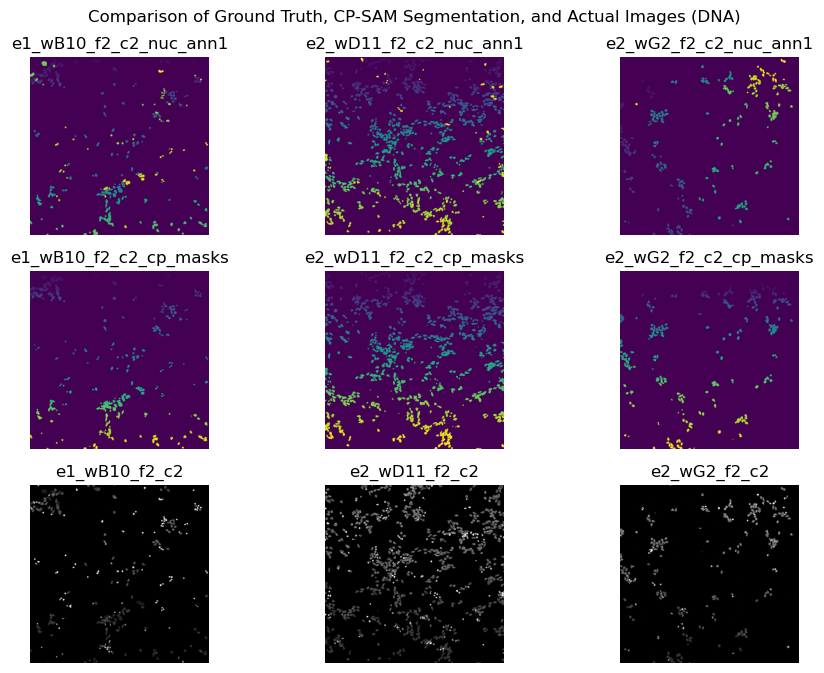

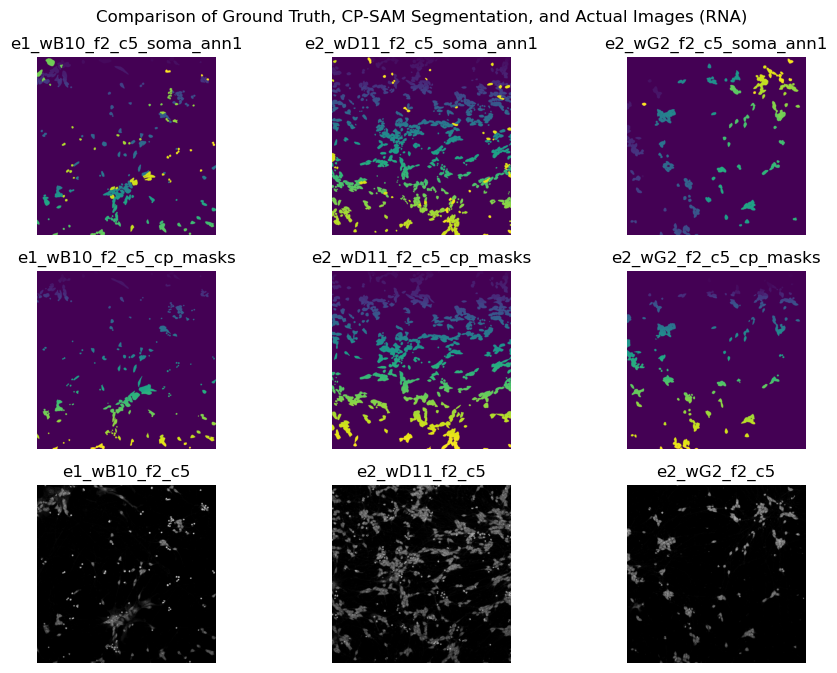

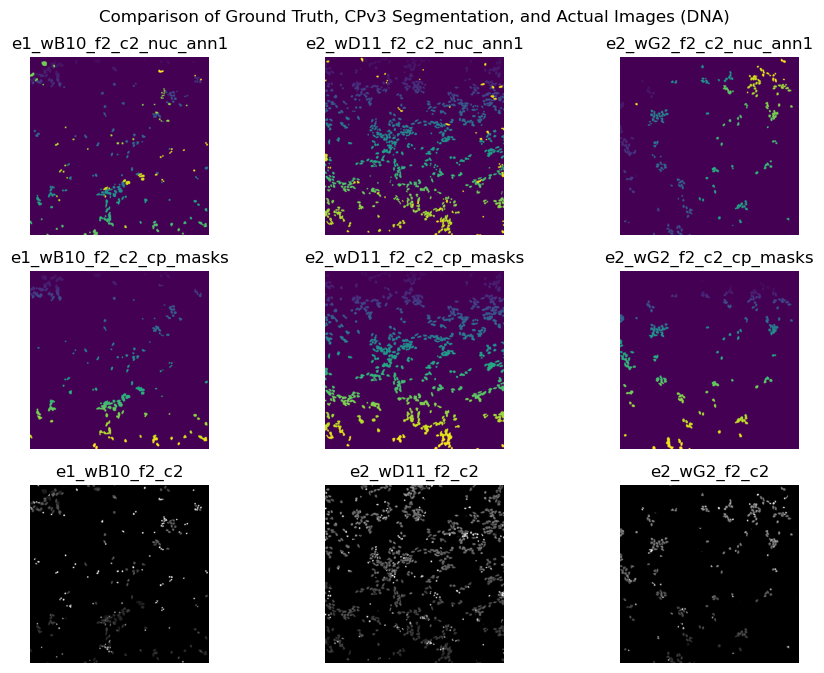

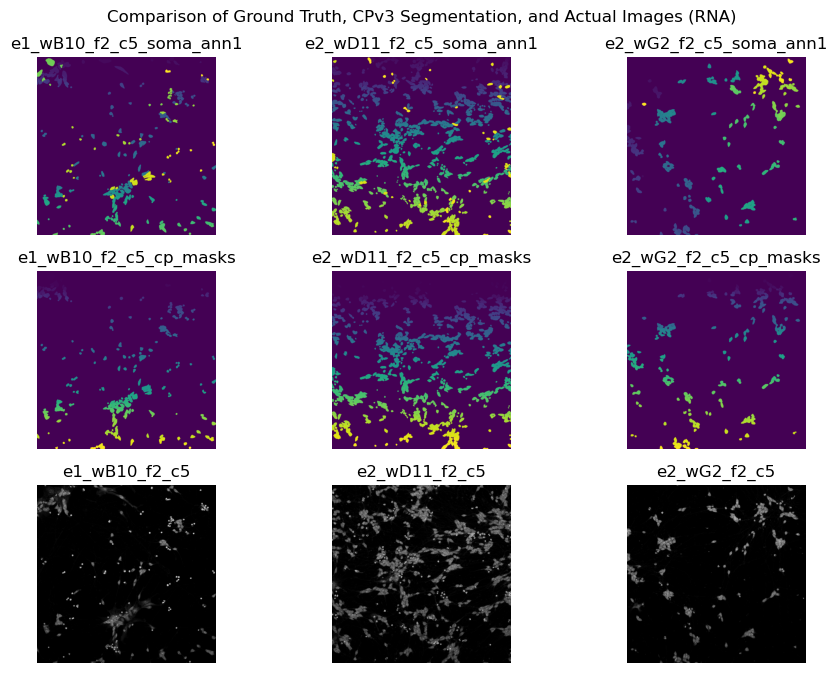

In [39]:
figures = [
    {
        "title": "Comparison of Ground Truth, CP-SAM Segmentation, and Actual Images (DNA)",
        "keys": ["e1_wB10_f2_c2", "e2_wD11_f2_c2", "e2_wG2_f2_c2"],
        "gt_key": "gt_nuc",
        "seg_key": "seg_nuc_CPSAM",
        "img_key": "image_dna"
    },
    {
        "title": "Comparison of Ground Truth, CP-SAM Segmentation, and Actual Images (RNA)",
        "keys": ["e1_wB10_f2_c5", "e2_wD11_f2_c5", "e2_wG2_f2_c5"],
        "gt_key": "gt_nuc",
        "seg_key": "seg_nuc_CPSAM",
        "img_key": "image_rna"
    },
    {
        "title": "Comparison of Ground Truth, CPv3 Segmentation, and Actual Images (DNA)",
        "keys": ["e1_wB10_f2_c2", "e2_wD11_f2_c2", "e2_wG2_f2_c2"],
        "gt_key": "gt_nuc",
        "seg_key": "seg_nuc_CPv3",
        "img_key": "image_dna"
    },
    {
        "title": "Comparison of Ground Truth, CPv3 Segmentation, and Actual Images (RNA)",
        "keys": ["e1_wB10_f2_c5", "e2_wD11_f2_c5", "e2_wG2_f2_c5"],
        "gt_key": "gt_nuc",
        "seg_key": "seg_nuc_CPv3",
        "img_key": "image_rna"
    }
]
#This function takes in the information from figures and plots the grid
def plot_grid(grid):
    plt.figure(figsize=(9, 9))
    plt.suptitle(grid["title"], fontsize=12, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    for idx, key in enumerate(grid["keys"]):
        #Ground Truth
        suffix_gt = "_nuc_ann1" if "dna" in grid["img_key"].lower() else "_soma_ann1"
        title_gt = f"{key}{suffix_gt}"
        plt.subplot(4, 3, idx + 1)
        plt.imshow(data[key][grid["gt_key"]])

        plt.title(title_gt)
        plt.axis("off")

        #Segmentation
        title_seg = f"{key}_cp_masks"
        plt.subplot(4, 3, idx + 4)
        plt.imshow(data[key][grid["seg_key"]])
        plt.title(title_seg)
        plt.axis("off")

        #Raw Image
        plt.subplot(4, 3, idx + 7)
        plt.imshow(data[key][grid["img_key"]], cmap="gray")
        plt.title(key)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

#Looping through the information in figures and calling plot_grid
for grid in figures:
    plot_grid(grid)



### Calculating Intersection over Union:


In [40]:
#This function takes two inputs: a ground truth image and a segmented image. It then compares the Intersection over Union for every nucleus in the image. The function returns a list representing the ID's used for the same nucleus in the different images and the Intersection over Union value they each have.
def match_labels_by_iou(imageGroundTruth, segmentation):
    #ID's for nuclei in the ground truth image and the segmentated image will be different for the same nucleus, so the matches list keeps track of the ID's that correlate to the same nucleus
    matches = []
    usedGTIds = []
    usedSegIds = []
    #np.unique(image) returns the unique elements of an array (in this project it would be the ID used to label each nucleus)
    for idGroundTruth in np.unique(imageGroundTruth):
        if idGroundTruth == 0:
            continue #We skip any background pixels, wich are represented by the ID zero.
        #The line below isolates one object at a time, and allows us to iterate over every nucleu instead of just clusters of pixels. 
        #It creates a mask for each specific nucleus every time we iterate
        #For example, if id = 2, this line below will create a mask of 1 for the pixels that show nucleus labeld with id = 2 and 0 for every other pixel (even pixels that depict other nuclei)
        maskGroundTruth = (imageGroundTruth == idGroundTruth)
        #Now that we have the mask for one specific nucleus in the ground truth, we can see which id in the segmentation correlates to the same area of pixels by calculating the highest intersection over union in the area of the mask
        best_IoU = 0
        best_idSeg = None
        for idSeg in np.unique(segmentation[maskGroundTruth]):
            if idSeg == 0:
                continue
            maskSeg = (segmentation == idSeg)
            intersection = np.logical_and(maskGroundTruth, maskSeg).sum()
            union = np.logical_or(maskGroundTruth, maskSeg).sum()
            if union == 0:
                continue #Skip any division by zero (in this project we won't have a case of union == 0 because we will always be testing an id that we know belongs to a nucleus)
            #If we get a higher IoU than what is currently set to best_IoU, we will replace the old value with the new one and we will update the idSeg for the matches[] list
            IoU = intersection/union
            if IoU > best_IoU:
                best_IoU = IoU
                best_idSeg = idSeg 
        #Checking to see that there is actually a match for the nucleus in the mask 
        #We have a threshold of 0.5 because there can’t have more than half of the pixels in two nuclei
        if (best_idSeg is not None) and (best_IoU > 0.5) and (best_idSeg not in usedSegIds) and (idGroundTruth not in usedGTIds):
            matches.append((int(idGroundTruth), int(best_idSeg), float(best_IoU)))
            usedGTIds.append(int(idGroundTruth))
            usedSegIds.append(int(best_idSeg))
        #elif best_idSeg is None and best_IoU == 0:
            #matches.append((int(idGroundTruth), None, 0))
    return(matches)

print("the list of matched ID's and the IoU values for a ground truth and segmented image is printed below:")
match_labels_by_iou(imageGT, imageSeg)

the list of matched ID's and the IoU values for a ground truth and segmented image is printed below:


[(1, 6, 0.8648148148148148),
 (2, 1, 0.9079497907949791),
 (3, 2, 0.9086538461538461),
 (4, 3, 0.8770764119601329),
 (5, 4, 0.9240506329113924),
 (6, 5, 0.7857142857142857),
 (7, 7, 0.8362068965517241),
 (8, 12, 0.9752475247524752),
 (9, 8, 0.8932038834951457),
 (11, 11, 0.9402985074626866),
 (12, 9, 0.8307210031347962),
 (13, 10, 0.9720670391061452),
 (14, 13, 0.9605263157894737),
 (15, 15, 0.9551569506726457),
 (17, 17, 0.9773242630385488),
 (19, 20, 0.8687258687258688),
 (20, 16, 0.9737373737373738),
 (21, 18, 0.7777777777777778),
 (22, 19, 0.9602649006622517),
 (23, 21, 0.9615384615384616),
 (24, 22, 0.9735449735449735),
 (25, 23, 0.9382716049382716),
 (26, 24, 0.87),
 (27, 25, 0.9702380952380952),
 (28, 26, 0.9447852760736196),
 (29, 27, 0.9382716049382716),
 (30, 29, 0.9420289855072463),
 (31, 32, 0.975),
 (32, 39, 0.9298043728423475),
 (33, 30, 0.9671361502347418),
 (34, 34, 0.9130434782608695),
 (35, 33, 0.9341317365269461),
 (36, 38, 0.9738219895287958),
 (37, 35, 0.9365079365

### True Positives, False Positives, False Negatives, Recall and Precision Values Calculator:

In [41]:
truePos = 0
falsePos = 0
falseNeg = 0
#True pos: length of matches
#False pos: Number of segmented ID's - Length of matches
#False pos: Number of ground truth ID's - Length of matches 
#Recall = truePos / (truePos + falseNeg)
#Precision = truePos / (truePos + falsePos)
def compute_tp_fp_fn_recall_precision(imageGroundTruth, segmentation):
    #Calculating tp, fp, and fn for recall and precision
    matchesList = match_labels_by_iou(imageGroundTruth, segmentation)
    matchesLength = len(matchesList)
    numOfGT_ID = len(np.unique(imageGroundTruth))-1
    numOfSeg_ID = len(np.unique(segmentation))-1
    truePos = matchesLength
    falsePos = numOfSeg_ID - matchesLength
    falseNeg =  numOfGT_ID - matchesLength
    recall = truePos / (truePos + falseNeg)
    precision = truePos / (truePos + falsePos)

    #Getting actual id's of tp, fp, and fn values
    matchesIDList = match_labels_by_iou(imageGroundTruth, segmentation)
    Gt_ID = np.unique(imageGroundTruth)
    Seg_ID = np.unique(segmentation)

    matched_gt_ids = [row[0] for row in matchesIDList]
    matched_seg_ids = [row[1] for row in matchesIDList]
    truePosIDListGT_ID = []
    truePosIDListSeg_ID = []

    #Creating lists with ID's from Ground Truth and Segmentation
    for row in matchesIDList:
        if row[0] != 0:
            truePosIDListGT_ID.append(row[0])
            truePosIDListSeg_ID.append(row[1])

    #From the Gt_ID list, if the current id is not in truePosIDListGT_ID (meaning it isn't a true positive), and isn't in the falsePosIDList, add it to the falseNegIDList
    falseNegIDList = []
    for i in range(0, len(Gt_ID)):
        if Gt_ID[i] != 0 and Gt_ID[i] not in truePosIDListGT_ID and Gt_ID[i] not in matched_gt_ids:
                falseNegIDList.append(int(Gt_ID[i]))


    falsePosIDList = []
    for i in range(0, len(Seg_ID)):
        if  Seg_ID[i] != 0 and Seg_ID[i] not in truePosIDListSeg_ID and Seg_ID[i] not in matched_seg_ids:
            falsePosIDList.append(int(Seg_ID[i]))

    return(recall, precision, truePosIDListGT_ID, falsePosIDList, falseNegIDList)

### Calculating Recall and Precision Values Calculator for CPSAM and CPv3 for Nuclei and Soma:

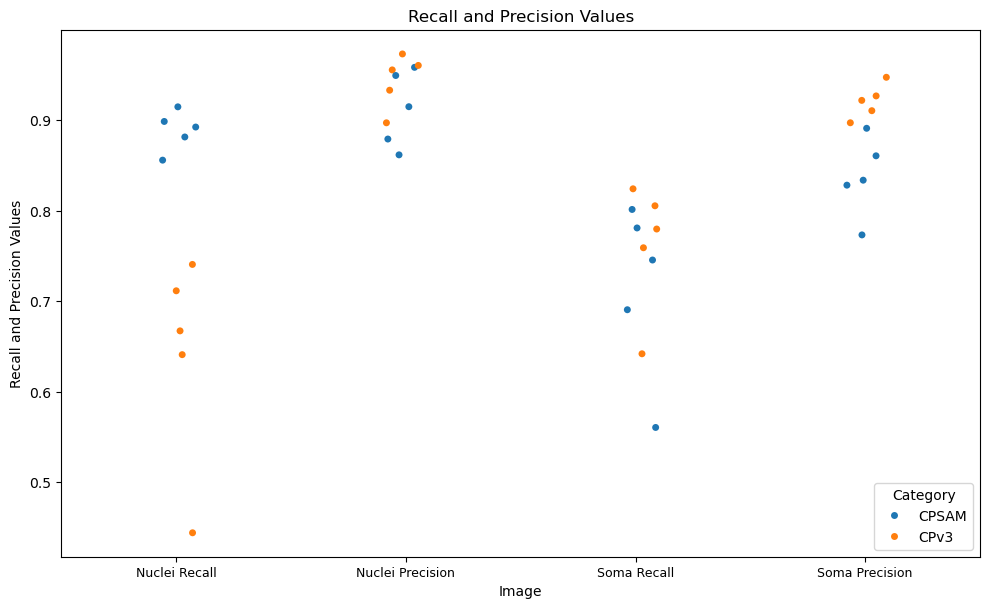

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

records = []

for key, images in data.items():
    gt = images["gt_nuc"]

    #Decide whether this is DNA or RNA based on the channel
    if key.endswith("c2"):
        label_recall = "Nuclei Recall"
        label_precision = "Nuclei Precision"
    elif key.endswith("c5"):
        label_recall = "Soma Recall"
        label_precision = "Soma Precision"

    recall, precision = compute_tp_fp_fn_recall_precision(gt, images["seg_nuc_CPSAM"])[:2]
    records.append((label_recall, recall, "CPSAM"))
    records.append((label_precision, precision, "CPSAM"))
    recall, precision = compute_tp_fp_fn_recall_precision(gt, images["seg_nuc_CPv3"])[:2]
    records.append((label_recall, recall, "CPv3"))
    records.append((label_precision, precision, "CPv3"))

dataPrecAndRecall = pd.DataFrame(records, columns=["Image", "Recall and Precision Values", "Category"])
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=dataPrecAndRecall,
    x="Image",
    y="Recall and Precision Values",
    hue="Category",
    dodge = False,
    jitter = True
)
plt.tight_layout()
plt.xticks(fontsize=9)
plt.title("Recall and Precision Values")
plt.legend(loc="lower right", title="Category")
plt.savefig("object_accuracy_CPSAM_vs_CPv3_DNA_and_RNA.png", dpi=300)
plt.show()


In [51]:
#This function takes in the data dictionary, a key to access a specific part of the dictionary, and a segmentation key.
#The function returns a color-coded image showing object-level True Positives, False Positives, and False Negative based
def color_tp_fp_fn(data, key, seg_key):
    #Accessing GT and Seg
    gt_nuc = data[key]["gt_nuc"]
    segmentation = data[key][seg_key]

    #Choose the correct raw image key depending on available keys
    if "image_dna" in data[key]:
        real_image = data[key]["image_dna"]
    elif "image_rna" in data[key]:
        real_image = data[key]["image_rna"]

    all_results = compute_tp_fp_fn_recall_precision(gt_nuc, segmentation)
    tp_ids = all_results[2]
    fp_ids = all_results[3]
    fn_ids = all_results[4]
    #Masks
    mask_tp = np.isin(gt_nuc, tp_ids).astype(float)
    mask_fn = np.isin(gt_nuc, fn_ids).astype(float)
    mask_fp = np.isin(segmentation, fp_ids).astype(float)

    #Color Maps
    green_cmap = ListedColormap([[0, 0, 0, 0], [0, 1, 0, 0.4]]) #[red, green, blue, transparency]
    blue_cmap = ListedColormap([[0, 0, 0, 0], [0, 0, 1, 0.4]])
    red_cmap = ListedColormap([[0, 0, 0, 0], [1, 0, 0, 0.4]])

    #Plotting
    fig = plt.figure(figsize=(6, 6), facecolor="none")
    plt.imshow(real_image, cmap="gray")
    plt.imshow(mask_tp, cmap=green_cmap)
    plt.imshow(mask_fn, cmap=blue_cmap)
    plt.imshow(mask_fp, cmap=red_cmap)
    plt.axis("off")
    plt.tight_layout()

    # Convert to PIL Image
    plt.figure(figsize=(6, 6), facecolor="none")
    plt.imshow(real_image, cmap="gray")
    plt.imshow(mask_tp, cmap=green_cmap)
    plt.imshow(mask_fn, cmap=blue_cmap)
    plt.imshow(mask_fp, cmap=red_cmap)
    plt.axis("off")
    plt.tight_layout()
    plt.show()




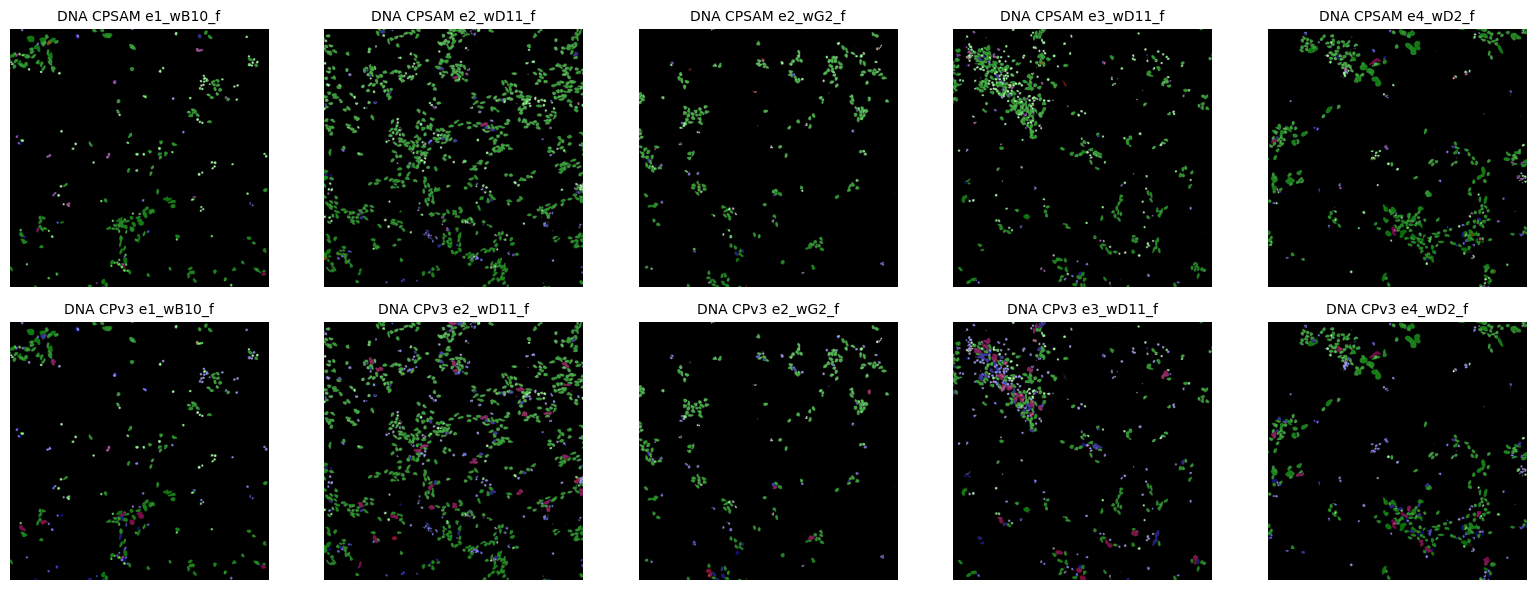

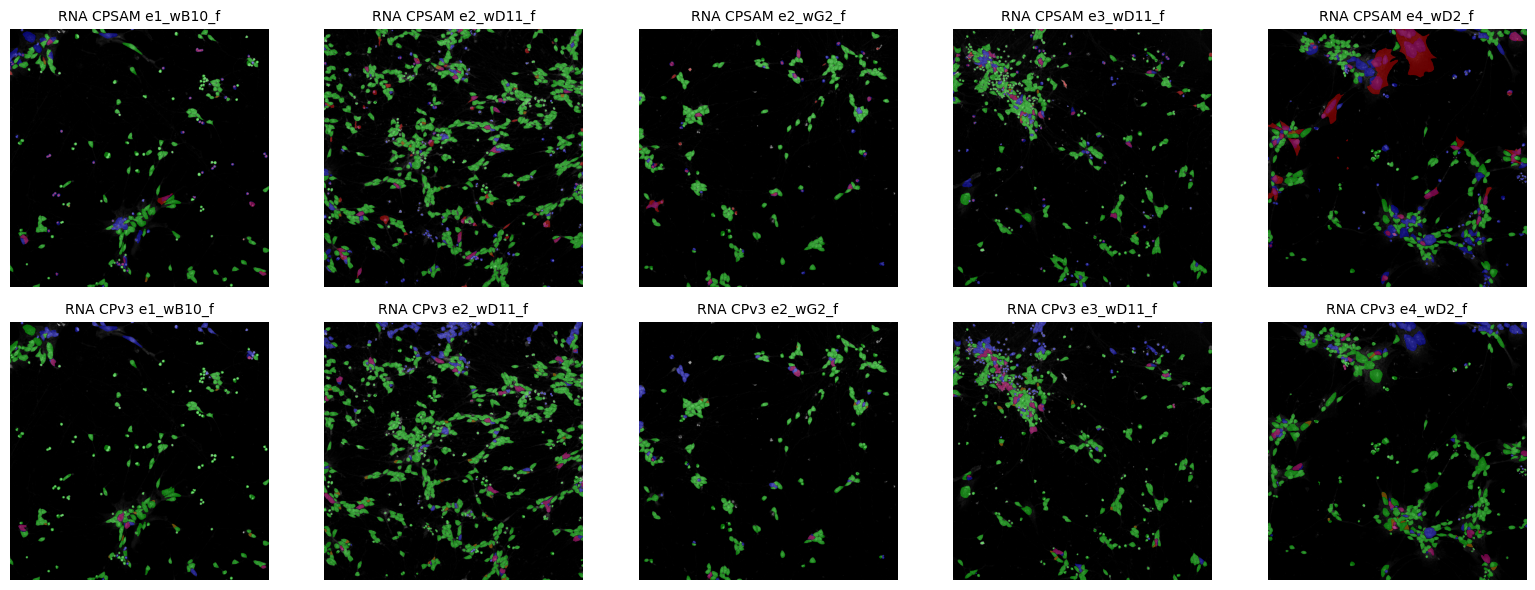

In [53]:
import matplotlib.pyplot as plt

dna_keys = ["e1_wB10_f2_c2", "e2_wD11_f2_c2", "e2_wG2_f2_c2", "e3_wD11_f3_c2", "e4_wD2_f2_c2"]

def color_tp_fp_fn(data, key, seg_key, ax=None):
    gt_nuc = data[key]["gt_nuc"]
    segmentation = data[key][seg_key]

    #Choose the correct raw image key
    if "image_dna" in data[key]:
        real_image = data[key]["image_dna"]
    elif "image_rna" in data[key]:
        real_image = data[key]["image_rna"]

    all_results = compute_tp_fp_fn_recall_precision(gt_nuc, segmentation)
    tp_ids = all_results[2]
    fp_ids = all_results[3]
    fn_ids = all_results[4]

    # Masks
    mask_tp = np.isin(gt_nuc, tp_ids).astype(float)
    mask_fn = np.isin(gt_nuc, fn_ids).astype(float)
    mask_fp = np.isin(segmentation, fp_ids).astype(float)

    #Color maps
    green_cmap = ListedColormap([[0, 0, 0, 0], [0, 1, 0, 0.4]])
    blue_cmap = ListedColormap([[0, 0, 0, 0], [0, 0, 1, 0.4]])
    red_cmap = ListedColormap([[0, 0, 0, 0], [1, 0, 0, 0.4]])

    #Plot on provided axis
    if ax is None:
        ax = plt.gca()
    ax.imshow(real_image, cmap="gray")
    ax.imshow(mask_tp, cmap=green_cmap)
    ax.imshow(mask_fn, cmap=blue_cmap)
    ax.imshow(mask_fp, cmap=red_cmap)
    ax.axis("off")


# Create subplots for DNA
fig, axes = plt.subplots(2, len(dna_keys), figsize=(16, 6))
fig.subplots_adjust(hspace=0.3)

# Row 1: CPSAM
for i, key in enumerate(dna_keys):
    color_tp_fp_fn(data, key, seg_key="seg_nuc_CPSAM", ax=axes[0, i])
    axes[0, i].set_title(f"DNA CPSAM {key[:-4]}", fontsize=10)

# Row 2: CPv3
for i, key in enumerate(dna_keys):
    color_tp_fp_fn(data, key, seg_key="seg_nuc_CPv3", ax=axes[1, i])
    axes[1, i].set_title(f"DNA CPv3 {key[:-4]}", fontsize=10)

plt.tight_layout()
plt.show()


#Create subplots for RNA
rna_keys = ["e1_wB10_f2_c5", "e2_wD11_f2_c5", "e2_wG2_f2_c5", "e3_wD11_f3_c5", "e4_wD2_f2_c5"]

fig, axes = plt.subplots(2, len(rna_keys), figsize=(16, 6))
fig.subplots_adjust(hspace=0.3)

#Row 1: CPSAM
for i, key in enumerate(rna_keys):
    color_tp_fp_fn(data, key, seg_key="seg_nuc_CPSAM", ax=axes[0, i])
    axes[0, i].set_title(f"RNA CPSAM {key[:-4]}", fontsize=10)

#Row 2: CPv3
for i, key in enumerate(rna_keys):
    color_tp_fp_fn(data, key, seg_key="seg_nuc_CPv3", ax=axes[1, i])
    axes[1, i].set_title(f"RNA CPv3 {key[:-4]}", fontsize=10)

plt.tight_layout()
plt.show()
